# Dataset Exploration

Load the hiragana data and look at a processed image.

## 1. Load the hiragana data

`load_hiragana()` reads all 46 character folders, converts every image to 28x28 grayscale, and inverts the pixel values (the Kaggle source images have a light background/dark ink, but we want a dark background/light stroke).

Sanity check here: 4600 images (46 characters x 100), a matching label list, and the first few class names in alphabetical order.

In [23]:
import sys
sys.path.append("../src")

from data_loader import load_hiragana

X, y, classes = load_hiragana("../data/kaggle_hiragana")
print(X.shape, y.shape)
print(classes[:5])

(4600, 28, 28) (4600,)
['aa', 'chi', 'ee', 'fu', 'ha']


## 2. Look at one image

`X[0]` is the 28x28 number matrix of the very first image, `y[0]` its label. Expectation: black background, light stroke (the inversion above worked), and the title should show "aa", since that's the first folder alphabetically.

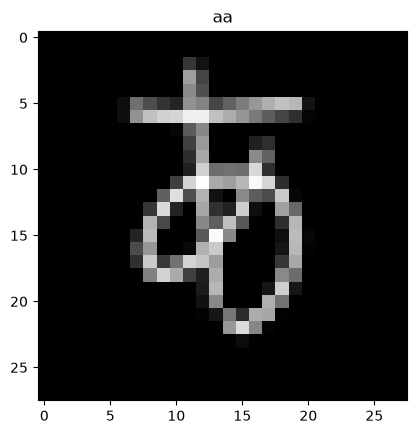

In [24]:
import matplotlib.pyplot as plt

plt.imshow(X[0], cmap="gray")
plt.title(classes[y[0]])
plt.show()

## 3. Look at an arbitrary index

`images` and `labels` are linked by index: `X[i]` belongs to `y[i]`. Here `i = 250` — since the inner loading loop goes through all 100 images of one folder before moving to the next, this already lands on the third character alphabetically (`aa`, `chi`, `ee`, ...). Change `i` to see other examples — try `i=99` and `i=100` to see the exact jump to the next character.

Label (Zahl): 2
Zeichen: ee


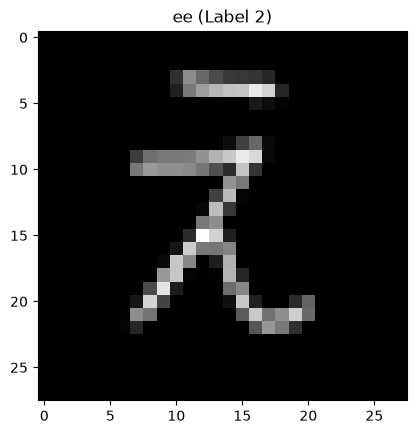

In [25]:
i = 250

print("Label (Zahl):", y[i])
print("Zeichen:", classes[y[i]])
plt.imshow(X[i], cmap="gray")
plt.title(f"{classes[y[i]]} (Label {y[i]})")
plt.show()

## 4. The raw numbers behind it

`plt.imshow()` only shows the graphical rendering. Here instead is the actual 28x28 matrix of numbers (0-255) behind it. The zeros at the edges are the black background; the non-zero values in the middle are the stroke. Below that, for comparison, the complete `y` list (4600 labels) — NumPy automatically truncates the display in the middle for arrays this long.

In [26]:
i = 250

print("Bild-Matrix (28x28 Werte von 0-255):")
print(X[i])

print("\nGesamte Labels-Liste (4600 Werte von 0-45):")
print(y)

Bild-Matrix (28x28 Werte von 0-255):
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  47 135 101  72  56  53  50  38
    1   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  30 116 150 174 184 187 224 201
   37   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  24  12
    3   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  

## 5. Image and numbers combined

A heatmap showing both at once: the gray shading per cell (like `imshow`) AND the normalized number (0.0-1.0) directly in the cell. This makes it easy to trace exactly which number corresponds to which visual brightness. This was the groundwork for later understanding what ReLU and the feature maps in the CNN actually do to these numbers (see `02_model_inspection.ipynb`).

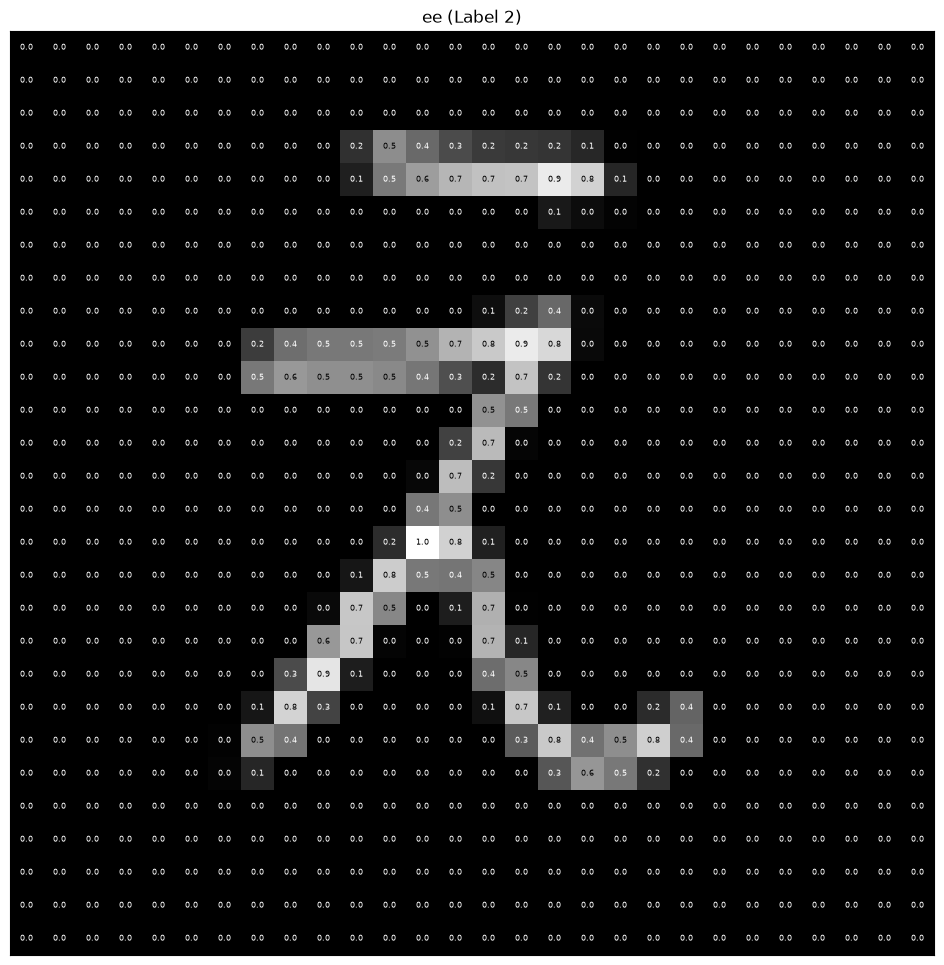

In [27]:
i = 250
img_norm = X[i] / 255.0

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(img_norm, cmap="gray")

for row in range(28):
    for col in range(28):
        value = img_norm[row, col]
        text_color = "black" if value > 0.5 else "white"
        ax.text(col, row, f"{value:.1f}", ha="center", va="center",
                 color=text_color, fontsize=6)

ax.set_title(f"{classes[y[i]]} (Label {y[i]})")
ax.set_xticks([])
ax.set_yticks([])
plt.show()